# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves. Thanks [Yandex Data School Analysis](https://github.com/yandexdataschool/Practical_DL/blob/fall21/week03_convnets/seminar_pytorch.ipynb) for this work!

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

![image](https://github.com/yandexdataschool/Practical_DL/raw/fall21/week03_convnets/cifar10.jpg)

In [1]:
# when running in colab, un-comment this
# !wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall19/week03_convnets/cifar.py

In [1]:
import numpy as np
from cifar import load_cifar10
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape,y_train.shape)

(40000, 3, 32, 32) (40000,)


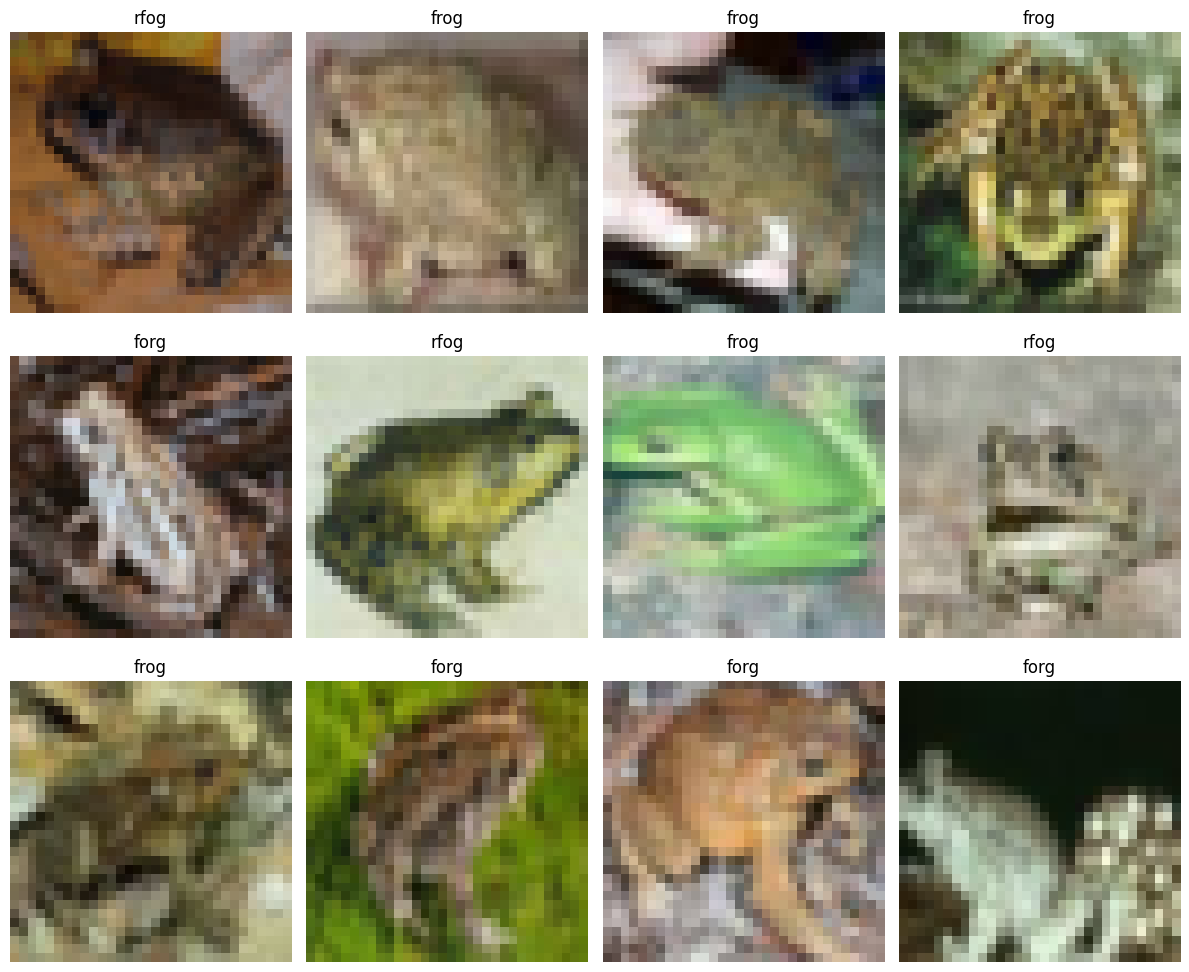

In [2]:
import random
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
i = 0
j = 123
while i < 12:
    if class_names[y_train[j]] == "frog":
        plt.subplot(3,4,i+1)
        name = random.choices(["frog", "forg", "rfog"])[0]
        plt.title(name)
        plt.imshow(np.transpose(X_train[j],[1,2,0]))
        plt.axis('off')
        i += 1
    j += 1

plt.tight_layout()
plt.show()

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

In [3]:
import torch, torch.nn as nn
import torch.nn.functional as F

# a special module that converts [batch, channel, w, h] to [batch, units]
class Flatten(nn.Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

Let's start with a dense network for our baseline:

In [4]:
model = nn.Sequential()

# reshape from "images" to flat vectors
model.add_module('flatten', Flatten())

# dense "head"
model.add_module('dense1', nn.Linear(3 * 32 * 32, 64))
model.add_module('dense1_relu', nn.ReLU())
model.add_module('dense2_logits', nn.Linear(64, 10)) # logits for 10 classes

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [5]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [7]:
# example
compute_loss(X_train[:5], y_train[:5])

tensor(2.3707, grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [6]:
# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [7]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

train_loss = []
val_accuracy = []

/home/eugen/coding/thesis/experiments/satlas-super-resolution/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import time
num_epochs = 50 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.data.numpy())
        
    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
        y_pred = logits.max(1)[1].data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))

    
    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 50 took 0.924s
  training loss (in-iteration): 	2.041510
  validation accuracy: 			32.77 %
Epoch 2 of 50 took 0.847s
  training loss (in-iteration): 	1.868619
  validation accuracy: 			36.18 %
Epoch 3 of 50 took 0.922s
  training loss (in-iteration): 	1.800755
  validation accuracy: 			37.36 %
Epoch 4 of 50 took 0.883s
  training loss (in-iteration): 	1.750948
  validation accuracy: 			39.55 %
Epoch 5 of 50 took 0.969s
  training loss (in-iteration): 	1.710108
  validation accuracy: 			40.20 %
Epoch 6 of 50 took 0.950s
  training loss (in-iteration): 	1.674901
  validation accuracy: 			42.18 %
Epoch 7 of 50 took 0.944s
  training loss (in-iteration): 	1.642162
  validation accuracy: 			42.61 %
Epoch 8 of 50 took 0.953s
  training loss (in-iteration): 	1.614303
  validation accuracy: 			43.23 %
Epoch 9 of 50 took 0.978s
  training loss (in-iteration): 	1.591056
  validation accuracy: 			41.32 %
Epoch 10 of 50 took 0.974s
  training loss (in-iteration): 	1.571590
  validation 

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [11]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)
    
print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		49.94 %
We need more magic! Follow instructons below


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

In [35]:
model = nn.Sequential(
    nn.Conv2d(3, 10, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(10, 20, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    Flatten(),
    nn.Linear(20 * 8 * 8, 100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [36]:
compute_loss(X_train[:5], y_train[:5])

tensor(2.3107, grad_fn=<MeanBackward0>)

In [37]:
import time
num_epochs = 35 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.data.numpy())

    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
        y_pred = logits.max(1)[1].data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))


    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 35 took 4.704s
  training loss (in-iteration): 	1.711692
  validation accuracy: 			49.92 %
Epoch 2 of 35 took 4.485s
  training loss (in-iteration): 	1.378069
  validation accuracy: 			55.23 %
Epoch 3 of 35 took 4.556s
  training loss (in-iteration): 	1.255144
  validation accuracy: 			57.50 %
Epoch 4 of 35 took 4.428s
  training loss (in-iteration): 	1.180652
  validation accuracy: 			59.48 %
Epoch 5 of 35 took 4.704s
  training loss (in-iteration): 	1.112010
  validation accuracy: 			61.24 %
Epoch 6 of 35 took 4.621s
  training loss (in-iteration): 	1.070314
  validation accuracy: 			62.57 %
Epoch 7 of 35 took 4.498s
  training loss (in-iteration): 	1.020116
  validation accuracy: 			62.95 %
Epoch 8 of 35 took 4.447s
  training loss (in-iteration): 	0.984216
  validation accuracy: 			63.17 %
Epoch 9 of 35 took 4.711s
  training loss (in-iteration): 	0.949279
  validation accuracy: 			63.82 %
Epoch 10 of 35 took 4.482s
  training loss (in-iteration): 	0.920107
  validation 

In [38]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		64.58 %
Achievement unlocked: 70lvl Warlock!


```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.



In [34]:
model = nn.Sequential(
    nn.Conv2d(3, 10, kernel_size=3, padding=1),
    nn.BatchNorm2d(10),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(10, 20, kernel_size=3, padding=1),
    nn.BatchNorm2d(20),
    nn.ReLU(),
    nn.MaxPool2d(2),

    Flatten(),
    nn.Linear(20 * 8 * 8, 100),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [35]:
compute_loss(X_train[:5], y_train[:5])

tensor(2.3468, grad_fn=<MeanBackward0>)

In [10]:
import time
num_epochs = 35 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.data.numpy())

    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
        y_pred = logits.max(1)[1].data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))


    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 35 took 5.787s
  training loss (in-iteration): 	1.325788
  validation accuracy: 			60.45 %
Epoch 2 of 35 took 6.291s
  training loss (in-iteration): 	1.026048
  validation accuracy: 			63.76 %
Epoch 3 of 35 took 6.855s
  training loss (in-iteration): 	0.904387
  validation accuracy: 			63.90 %
Epoch 4 of 35 took 5.776s
  training loss (in-iteration): 	0.823223
  validation accuracy: 			65.37 %
Epoch 5 of 35 took 6.507s
  training loss (in-iteration): 	0.762070
  validation accuracy: 			67.45 %
Epoch 6 of 35 took 6.243s
  training loss (in-iteration): 	0.706725
  validation accuracy: 			64.30 %
Epoch 7 of 35 took 5.892s
  training loss (in-iteration): 	0.655439
  validation accuracy: 			68.36 %
Epoch 8 of 35 took 5.531s
  training loss (in-iteration): 	0.609152
  validation accuracy: 			66.09 %
Epoch 9 of 35 took 5.971s
  training loss (in-iteration): 	0.573711
  validation accuracy: 			68.50 %
Epoch 10 of 35 took 5.910s
  training loss (in-iteration): 	0.527119
  validation 

In [11]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32))
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		65.37 %
Achievement unlocked: 70lvl Warlock!



```

```

```

```

```

```

```

```

```

```

```

```

```

```
## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [27]:
from torchvision import transforms
means = np.array((0.4914, 0.4822, 0.4465))
stds = np.array((0.2023, 0.1994, 0.2010))

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

In [41]:
from torchvision.datasets import CIFAR10


full_dataset = CIFAR10("./cifar_data/", train=True)
train_frac = 0.8
len_all = len(full_dataset)
len_train = int(len_all * train_frac)
train_indices, val_indices = torch.utils.data.random_split(range(len_all), [len_train, len_all - len_train], generator=torch.Generator().manual_seed(42))


train_dataset = torch.utils.data.Subset(CIFAR10("./cifar_data/", train=True, transform=transform_augment), train_indices)

train_batch_gen = torch.utils.data.DataLoader(train_dataset,
                                              batch_size=256,
                                              shuffle=True,
                                              num_workers=1)

When testing, we don't need random crops, just normalize with same statistics.

In [42]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

test_dataset = CIFAR10("./cifar_data/", train=False, transform=transform_test, download=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=2)

Files already downloaded and verified


In [43]:
val_dataset = torch.utils.data.Subset(CIFAR10("./cifar_data/", train=True, transform=transform_test, download=True), val_indices)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=512, shuffle=False, num_workers=2)

Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.754760736716321e-08..0.9999999852895738].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.754760736716321e-08..0.9999999885559081].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.754760736716321e-08..0.9999999852895738].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.754760736716321e-08..0.9725490579605103].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.754760736716321e-08..0.9999999885559081].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.754760736716321e-08..0.8745098115444183].
Clip

X: <class 'torch.Tensor'> torch.Size([256, 3, 32, 32])
y: <class 'torch.Tensor'> torch.Size([256])


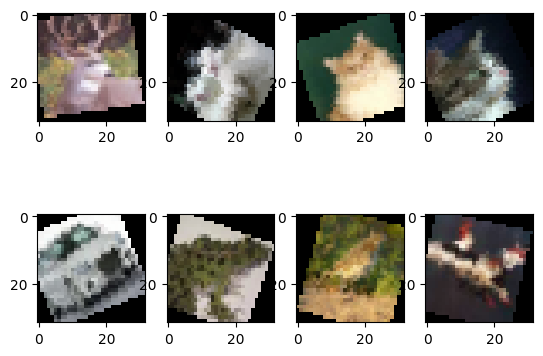

In [44]:

for (x_batch, y_batch) in train_batch_gen:

    print('X:', type(x_batch), x_batch.shape)
    print('y:', type(y_batch), y_batch.shape)

    for i, img in enumerate(x_batch.numpy()[:8]):
        plt.subplot(2, 4, i+1)
        plt.imshow(img.transpose([1,2,0]) * stds + means )


    break

In [45]:
# Reset the model
model = nn.Sequential(
    nn.Conv2d(3, 10, kernel_size=3, padding=1),
    nn.BatchNorm2d(10),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(10, 20, kernel_size=3, padding=1),
    nn.BatchNorm2d(20),
    nn.ReLU(),
    nn.MaxPool2d(2),

    Flatten(),
    nn.Linear(20 * 8 * 8, 100),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [46]:
train_loss = []
val_accuracy = []
num_epochs = 35

for epoch in range(num_epochs):
    start_time = time.time()
    model.train(True)
    for X_batch, y_batch in train_batch_gen:
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.data.numpy())

    model.train(False)
    for X_batch, y_batch in val_loader:
        logits = model(X_batch)
        y_pred = logits.max(1)[1].data.numpy()
        val_accuracy.append(np.mean(y_batch.numpy() == y_pred))

    print( "Epoch {} of {} took {:.3f}s ".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print( "  training loss (in-iteration): \t{:.6f} ".format(
        np.mean(train_loss[-len(train_batch_gen):])))
    print( "  validation accuracy: \t\t\t{:.2f} % ".format(
        np.mean(val_accuracy[-len(test_loader):]) * 100))

Epoch 1 of 35 took 17.563s 
  training loss (in-iteration): 	1.678913 
  validation accuracy: 			49.27 % 
Epoch 2 of 35 took 17.257s 
  training loss (in-iteration): 	1.441998 
  validation accuracy: 			55.00 % 
Epoch 3 of 35 took 17.965s 
  training loss (in-iteration): 	1.363924 
  validation accuracy: 			57.99 % 
Epoch 4 of 35 took 17.502s 
  training loss (in-iteration): 	1.312664 
  validation accuracy: 			60.25 % 
Epoch 5 of 35 took 16.634s 
  training loss (in-iteration): 	1.273201 
  validation accuracy: 			60.51 % 
Epoch 6 of 35 took 17.881s 
  training loss (in-iteration): 	1.248770 
  validation accuracy: 			61.70 % 
Epoch 7 of 35 took 17.954s 
  training loss (in-iteration): 	1.223075 
  validation accuracy: 			62.43 % 
Epoch 8 of 35 took 18.282s 
  training loss (in-iteration): 	1.204113 
  validation accuracy: 			63.55 % 
Epoch 9 of 35 took 17.304s 
  training loss (in-iteration): 	1.191734 
  validation accuracy: 			63.08 % 
Epoch 10 of 35 took 19.475s 
  training loss (

In [48]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in test_loader:
    logits = model(X_batch)
    y_pred = logits.max(1)[1].data.numpy()
    test_batch_acc.append(np.mean(y_batch.numpy() == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		69.58 %
Achievement unlocked: 70lvl Warlock!


# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.
 
## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons, 
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.
 
   
### Data augmemntation
   * getting 5x as large dataset for free is a great 
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image): 
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


In [49]:
class CifarNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32 -> 16x16

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16 -> 8x8

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_hw = CifarNet().cuda() if torch.cuda.is_available() else CifarNet()
opt_hw = torch.optim.AdamW(model_hw.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt_hw, T_max=100)

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_hw.to(device)

num_epochs = 100
best_acc = 0.0

for epoch in range(num_epochs):
    model_hw.train()
    epoch_loss = []

    for X_batch, y_batch in train_batch_gen:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        opt_hw.zero_grad()
        logits = model_hw(X_batch)
        loss = F.cross_entropy(logits, y_batch)
        loss.backward()
        opt_hw.step()
        epoch_loss.append(loss.item())

    scheduler.step()  # LR decay

    # Validation
    model_hw.eval()
    correct = 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            preds = model_hw(X_val).argmax(1)
            correct += (preds == y_val).sum().item()

    val_acc = correct / len(test_dataset)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_hw.state_dict(), "best_hw_model.pth")

    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {np.mean(epoch_loss):.4f} | Val Acc: {val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

print(f"\nBest Validation Accuracy: {best_acc:.4f}")

Epoch   1 | Loss: 1.5748 | Val Acc: 0.5118 | LR: 0.001000
Epoch  10 | Loss: 0.7033 | Val Acc: 0.7728 | LR: 0.000976
Epoch  20 | Loss: 0.4923 | Val Acc: 0.8244 | LR: 0.000905
Epoch  30 | Loss: 0.3876 | Val Acc: 0.8443 | LR: 0.000794
Epoch  40 | Loss: 0.3125 | Val Acc: 0.8646 | LR: 0.000655
Epoch  50 | Loss: 0.2575 | Val Acc: 0.8726 | LR: 0.000500
Epoch  60 | Loss: 0.2119 | Val Acc: 0.8793 | LR: 0.000345
Epoch  70 | Loss: 0.1700 | Val Acc: 0.8864 | LR: 0.000206
Epoch  80 | Loss: 0.1401 | Val Acc: 0.8909 | LR: 0.000095
Epoch  90 | Loss: 0.1237 | Val Acc: 0.8919 | LR: 0.000024
Epoch 100 | Loss: 0.1222 | Val Acc: 0.8913 | LR: 0.000000

Best Validation Accuracy: 0.8937


In [51]:
model_hw.load_state_dict(torch.load("best_hw_model.pth"))
model_hw.eval()
correct = 0
with torch.no_grad():
    for X, y in test_loader:
        correct += (model_hw(X.to(device)).argmax(1) == y.to(device)).sum().item()
print(f"Test Accuracy: {correct/len(test_dataset):.4f}")

Test Accuracy: 0.8835
